# Decision trees: numbers for the video

Every number the Manim scenes show comes from here. Run this top to bottom
(`make data`) and it rewrites `data/*.json`:

| file | used by | contents |
|---|---|---|
| `balls.json` | scenes 3–5, 9–10 | the 20-ball example: entropies, IG for every threshold, the greedy tree |
| `toy2d.json` | scenes 6–7, 9 | 2D toy dataset, trees at depth 1…10 and unlimited: splits, segments, leaf rectangles |
| `depth_cv.json` | scene 9 | train / CV accuracy vs. `max_depth` |
| `twenty_questions.json` | scene 2 | candidate counts for the Twenty Questions game |
| `regression.json` | scene 10 | noisy-function data, `f(x)`, step-function fits at several depths |

Source: [mlcourse.ai Topic 3](https://mlcourse.ai/book/topic03/topic03_decision_trees_kNN.html).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

SEED = 17  # the article uses 17 everywhere
DATA = Path.cwd() if Path.cwd().name == "data" else Path.cwd() / "data"
META = {
    "source": "https://mlcourse.ai/book/topic03/topic03_decision_trees_kNN.html",
    "generated_by": "data/compute.ipynb",
    "sklearn": sklearn.__version__,
    "numpy": np.__version__,
}


def r(x, nd=6):
    """Round floats (and nested lists of floats) so the JSON stays readable."""
    if isinstance(x, (list, tuple, np.ndarray)):
        return [r(v, nd) for v in x]
    return round(float(x), nd)


def entropy(counts):
    counts = np.asarray(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-(p * np.log2(p)).sum()) + 0.0  # + 0.0 turns -0.0 into 0.0


def info_gain(parent, children):
    n = sum(sum(c) for c in children)
    return entropy(parent) - sum(sum(c) / n * entropy(c) for c in children)


def dump(name, obj):
    path = DATA / name
    path.write_text(json.dumps({"meta": META, **obj}, indent=1) + "\n")
    print(f"wrote {path}  ({path.stat().st_size / 1024:.1f} KB)")

In [2]:
def tree_nodes(model, class_names=None):
    """Flatten a fitted sklearn tree into a list of nodes (index = node id).

    Internal nodes test `x[feature] <= threshold`; `left` is the True branch.
    For classifiers `counts` holds per-class sample counts; for regressors `value` is the mean.
    """
    t = model.tree_
    depth = np.zeros(t.node_count, dtype=int)
    for i in range(t.node_count):
        for c in (t.children_left[i], t.children_right[i]):
            if c != -1:
                depth[c] = depth[i] + 1
    is_clf = class_names is not None
    nodes = []
    for i in range(t.node_count):
        leaf = t.children_left[i] == -1
        node = {"id": i, "depth": int(depth[i]), "leaf": bool(leaf), "samples": int(t.n_node_samples[i])}
        if is_clf:
            # value_ holds class fractions in recent sklearn; turn it back into counts
            counts = np.rint(t.value[i, 0] / t.value[i, 0].sum() * t.n_node_samples[i]).astype(int)
            node["counts"] = counts.tolist()
            node["impurity"] = r(t.impurity[i])
            node["prediction"] = class_names[int(np.argmax(counts))]
        else:
            node["value"] = r(t.value[i, 0, 0])
            node["impurity"] = r(t.impurity[i])  # variance (MSE) of the node
        if not leaf:
            left, right = int(t.children_left[i]), int(t.children_right[i])
            n, nl, nr = t.n_node_samples[i], t.n_node_samples[left], t.n_node_samples[right]
            gain = t.impurity[i] - nl / n * t.impurity[left] - nr / n * t.impurity[right]
            node.update(feature=int(t.feature[i]), threshold=r(t.threshold[i]),
                        left=left, right=right, gain=r(gain))
        nodes.append(node)
    return nodes


def regions(nodes, bounds):
    """Walk the tree carrying an axis-aligned box.

    Returns (segments, leaves): one cut segment per internal node (clipped to its parent's
    box, so drawing them in node order animates the partition) and one rectangle per leaf.
    bounds = [[x1_min, x1_max], [x2_min, x2_max]].
    """
    segments, leaves = [], []

    def walk(i, box):
        n = nodes[i]
        if n["leaf"]:
            leaves.append({"node": i, "box": r(box), "prediction": n["prediction"], "counts": n["counts"]})
            return
        f, thr = n["feature"], n["threshold"]
        other = box[1 - f]
        a, b = [0.0, 0.0], [0.0, 0.0]
        a[f] = b[f] = thr
        a[1 - f], b[1 - f] = other
        segments.append({"node": i, "depth": n["depth"], "feature": f, "threshold": thr, "start": r(a), "end": r(b)})
        lo, hi = [list(x) for x in box], [list(x) for x in box]
        lo[f][1] = thr
        hi[f][0] = thr
        walk(n["left"], lo)
        walk(n["right"], hi)

    walk(0, [list(b) for b in bounds])
    return segments, leaves

## 1. The 20 balls

The article has no code for this example. The colors come from its pictures
(`decision_tree3.png`, `topic3_entropy_balls2.png`). Ball *i* sits at position *x = i*.

In [3]:
BALLS = "Y B B B B Y Y Y Y B B B B Y Y Y Y Y Y B".split()
colors = ["blue" if b == "B" else "yellow" for b in BALLS]
x = np.arange(len(BALLS))
y = np.array([c == "yellow" for c in colors], dtype=int)  # 0 = blue, 1 = yellow


def counts_of(mask):
    return [int((y[mask] == 0).sum()), int((y[mask] == 1).sum())]  # [blue, yellow]


root = counts_of(x >= 0)
left, right = counts_of(x <= 12), counts_of(x > 12)
assert root == [9, 11] and left == [8, 5] and right == [1, 6], "ball colors don't match the article"

S0, S1, S2 = entropy(root), entropy(left), entropy(right)
IG12 = info_gain(root, [left, right])
print(f"S0 = {S0:.4f}  S1 = {S1:.4f}  S2 = {S2:.4f}  IG(x<=12) = {IG12:.4f}")

S0 = 0.9928  S1 = 0.9612  S2 = 0.5917  IG(x<=12) = 0.1609


best threshold: x <= 12  IG = 0.160885


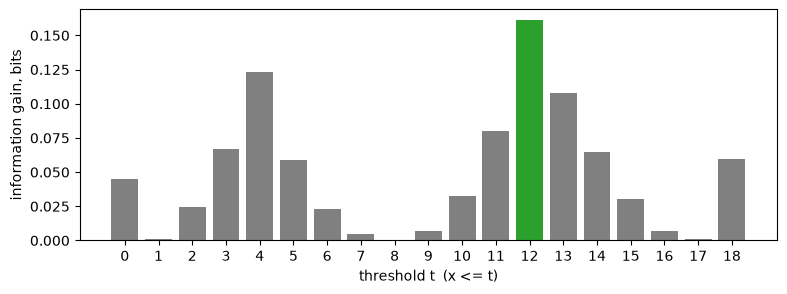

In [4]:
# IG for every threshold "x <= t", t = 0..18
thresholds = []
for t in range(len(BALLS) - 1):
    L, R = counts_of(x <= t), counts_of(x > t)
    thresholds.append({"t": t, "left": L, "right": R,
                       "S_left": r(entropy(L)), "S_right": r(entropy(R)),
                       "ig": r(info_gain(root, [L, R]))})
best = max(thresholds, key=lambda d: d["ig"])
print("best threshold: x <=", best["t"], " IG =", best["ig"])

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar([d["t"] for d in thresholds], [d["ig"] for d in thresholds],
       color=["tab:green" if d is best else "grey" for d in thresholds])
ax.set(xlabel="threshold t  (x <= t)", ylabel="information gain, bits", xticks=range(19));

In [5]:
# The greedy tree. Positions are integers, so sklearn's threshold 12.5 is the question "x <= 12".
ball_tree = DecisionTreeClassifier(criterion="entropy", random_state=SEED).fit(x.reshape(-1, 1), y)
ball_nodes = tree_nodes(ball_tree, class_names=["blue", "yellow"])
for n in ball_nodes:
    if not n["leaf"]:
        n["question"] = f"x <= {int(np.floor(n['threshold']))}"
        n["t"] = int(np.floor(n["threshold"]))
    n["balls"] = [int(i) for i in x[ball_tree.decision_path(x.reshape(-1, 1)).toarray()[:, n["id"]] == 1]]
n_questions = sum(not n["leaf"] for n in ball_nodes)
assert ball_nodes[0]["question"] == "x <= 12" and n_questions == 5, "tree doesn't match the article"
assert ball_tree.score(x.reshape(-1, 1), y) == 1.0

for n in ball_nodes:
    print("  " * n["depth"] + (n.get("question") or f"leaf {n['prediction']}"), n["counts"], n["balls"])

x <= 12 [9, 11] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  x <= 8 [8, 5] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    x <= 4 [4, 5] [0, 1, 2, 3, 4, 5, 6, 7, 8]
      x <= 0 [4, 1] [0, 1, 2, 3, 4]
        leaf yellow [0, 1] [0]
        leaf blue [4, 0] [1, 2, 3, 4]
      leaf yellow [0, 4] [5, 6, 7, 8]
    leaf blue [4, 0] [9, 10, 11, 12]
  x <= 18 [1, 6] [13, 14, 15, 16, 17, 18, 19]
    leaf yellow [0, 6] [13, 14, 15, 16, 17, 18]
    leaf blue [1, 0] [19]


In [6]:
# Reference jars for scene 3 ("all yellow / one blue / ten-ten") and the per-color surprisal tags
jars = [{"blue": b, "yellow": 20 - b, "entropy": r(entropy([b, 20 - b]))} for b in range(21)]
surprisal = {"blue": r(np.log2(20 / 9)), "yellow": r(np.log2(20 / 11))}

dump("balls.json", {
    "colors": colors,                      # index = position x
    "counts": {"blue": root[0], "yellow": root[1]},
    "entropy": {"S0": r(S0), "S1": r(S1), "S2": r(S2)},   # all / x<=12 / x>12
    "split_12": {"left": left, "right": right, "ig": r(IG12),
                 "weights": [sum(left) / 20, sum(right) / 20]},
    "surprisal": surprisal,                # log2(1/p) for each color
    "jars": jars,                          # entropy of b blue + (20-b) yellow
    "thresholds": thresholds,              # one per "x <= t", t = 0..18; counts are [blue, yellow]
    "best_threshold": best["t"],
    "tree": {"n_questions": n_questions, "nodes": ball_nodes},
})

wrote /Users/kashnitsky/Documents/learning_side_hassle/3b1b_mlcourse_claude/data/balls.json  (8.1 KB)


## 2. The 2D toy dataset

The same code as the article: 100 points from N(0, I) (class 0), then 100 from N((2, 2), I) (class 1), seed 17.
Trees use `criterion="entropy"`. The box is the article's `get_grid` range (data ± 1).

In [7]:
np.random.seed(SEED)
train_data = np.random.normal(size=(100, 2))
train_labels = np.zeros(100)
train_data = np.r_[train_data, np.random.normal(size=(100, 2), loc=2)]
train_labels = np.r_[train_labels, np.ones(100)]

bounds = [[train_data[:, 0].min() - 1, train_data[:, 0].max() + 1],
          [train_data[:, 1].min() - 1, train_data[:, 1].max() + 1]]
DEPTHS = list(range(1, 11)) + [None]  # None = grow until pure

trees2d = []
for d in DEPTHS:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED).fit(train_data, train_labels)
    nodes = tree_nodes(clf, class_names=[0, 1])
    segments, leaves = regions(nodes, bounds)
    trees2d.append({"max_depth": d, "actual_depth": int(clf.get_depth()), "n_leaves": int(clf.get_n_leaves()),
                    "train_accuracy": r(clf.score(train_data, train_labels)),
                    "nodes": nodes, "segments": segments, "leaves": leaves})
    print(f"max_depth={d!s:>4}  depth={clf.get_depth():2d}  leaves={clf.get_n_leaves():3d}  "
          f"train acc={clf.score(train_data, train_labels):.3f}")

max_depth=   1  depth= 1  leaves=  2  train acc=0.855
max_depth=   2  depth= 2  leaves=  4  train acc=0.915
max_depth=   3  depth= 3  leaves=  8  train acc=0.930
max_depth=   4  depth= 4  leaves= 12  train acc=0.955
max_depth=   5  depth= 5  leaves= 15  train acc=0.960
max_depth=   6  depth= 6  leaves= 18  train acc=0.965
max_depth=   7  depth= 7  leaves= 20  train acc=0.980
max_depth=   8  depth= 8  leaves= 22  train acc=0.990
max_depth=   9  depth= 9  leaves= 23  train acc=0.990
max_depth=  10  depth=10  leaves= 24  train acc=0.995
max_depth=None  depth=12  leaves= 26  train acc=1.000


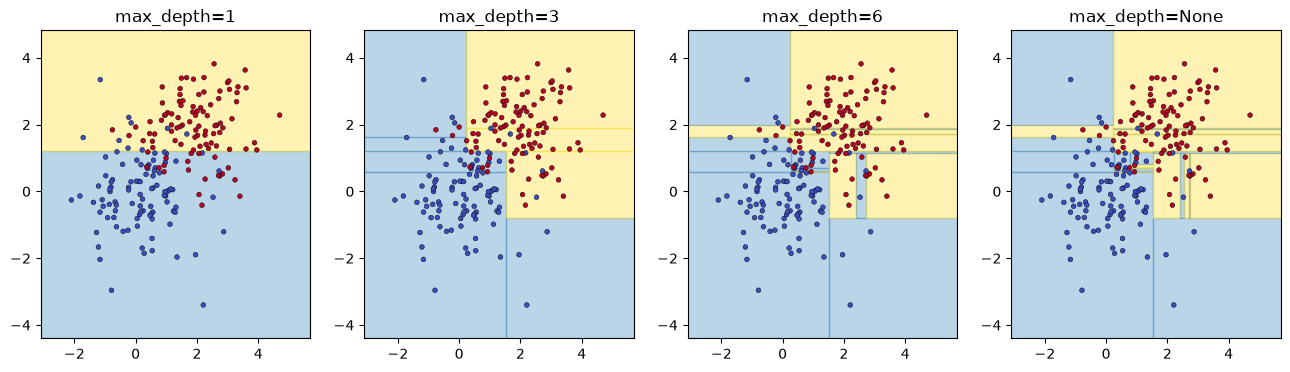

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, tr in zip(axes, [trees2d[0], trees2d[2], trees2d[5], trees2d[-1]]):
    for lf in tr["leaves"]:
        (x0, x1), (y0, y1) = lf["box"]
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, alpha=0.3,
                                   color="tab:blue" if lf["prediction"] == 0 else "gold"))
    ax.scatter(*train_data.T, c=train_labels, cmap="coolwarm", s=12, edgecolors="k", lw=0.3)
    ax.set(xlim=bounds[0], ylim=bounds[1], title=f"max_depth={tr['max_depth']}")

In [9]:
dump("toy2d.json", {
    "seed": SEED,
    "points": [{"x": r(p, 4), "label": int(l)} for p, l in zip(train_data, train_labels)],
    "bounds": r(bounds, 4),                # [[x1_min, x1_max], [x2_min, x2_max]]
    "article_line": {"from": [-2, 4], "to": [4, -2]},   # the diagonal x2 = 2 - x1 the article draws
    "root_entropy": r(entropy([100, 100])),
    "trees": trees2d,                      # max_depth = null means unlimited
})

wrote /Users/kashnitsky/Documents/learning_side_hassle/3b1b_mlcourse_claude/data/toy2d.json  (155.7 KB)


## 3. Accuracy vs. depth

Train accuracy against held-out accuracy on the same 200 points, using stratified 5-fold CV repeated 10 times
so the curve is smooth.

best depth by CV: 4  CV acc = 0.8795


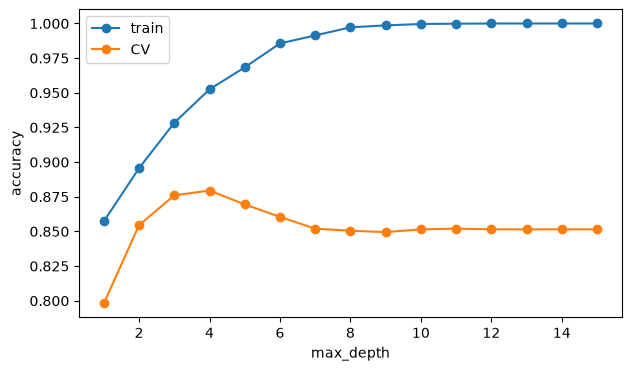

In [10]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
cv_depths = list(range(1, 16))
rows = []
for d in cv_depths:
    res = cross_validate(DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED),
                         train_data, train_labels, cv=cv, return_train_score=True)
    rows.append({"max_depth": d,
                 "train_mean": r(res["train_score"].mean()), "train_std": r(res["train_score"].std()),
                 "test_mean": r(res["test_score"].mean()), "test_std": r(res["test_score"].std())})
best_cv = max(rows, key=lambda row: row["test_mean"])
print("best depth by CV:", best_cv["max_depth"], " CV acc =", best_cv["test_mean"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cv_depths, [row["train_mean"] for row in rows], "o-", label="train")
ax.plot(cv_depths, [row["test_mean"] for row in rows], "o-", label="CV")
ax.set(xlabel="max_depth", ylabel="accuracy"); ax.legend();

In [11]:
dump("depth_cv.json", {
    "cv": {"n_splits": 5, "n_repeats": 10, "stratified": True, "random_state": SEED},
    "rows": rows,
    "best_depth": best_cv["max_depth"],
})

wrote /Users/kashnitsky/Documents/learning_side_hassle/3b1b_mlcourse_claude/data/depth_cv.json  (2.1 KB)


## 4. Regression tree on the noisy function

f(x) = exp(−x²) + 1.5·exp(−(x − 2)²), 150 training points on [−5, 5], noise σ = 0.1.
The code matches the article. It reseeds with 17 because the article never seeds this cell.
A fit is a step function, exported as sorted `thresholds` plus `values` (`len(values) = len(thresholds) + 1`):
the prediction is `values[k]` on the k-th interval, and it stays flat beyond the outermost thresholds.

In [12]:
n_train, n_test, noise = 150, 1000, 0.1


def f(x):
    x = x.ravel()
    return np.exp(-(x**2)) + 1.5 * np.exp(-((x - 2) ** 2))


def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-(X**2)) + 1.5 * np.exp(-((X - 2) ** 2)) + np.random.normal(0.0, noise, n_samples)
    return X.reshape((n_samples, 1)), y


np.random.seed(SEED)
X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

REG_DEPTHS = [1, 2, 3, 4, 5, 6]
fits = [{"max_depth": 0, "thresholds": [], "values": [r(y_train.mean())],
         "train_mse": r(y_train.var()), "test_mse": r(((y_test - y_train.mean()) ** 2).mean())}]
for d in REG_DEPTHS:
    reg = DecisionTreeRegressor(max_depth=d, random_state=SEED).fit(X_train, y_train)
    nodes = tree_nodes(reg)
    thr = sorted(n["threshold"] for n in nodes if not n["leaf"])
    mids = np.array([-1e9] + thr) + np.diff([-1e9] + thr + [1e9]) / 2  # one probe point per interval
    mids[0], mids[-1] = (thr[0] - 1, thr[-1] + 1) if thr else (0, 0)
    fits.append({"max_depth": d, "thresholds": thr, "values": r(reg.predict(mids.reshape(-1, 1))),
                 "train_mse": r(((y_train - reg.predict(X_train)) ** 2).mean()),
                 "test_mse": r(((y_test - reg.predict(X_test)) ** 2).mean()),
                 "nodes": nodes})
    print(f"max_depth={d}  steps={len(thr) + 1:2d}  test MSE={fits[-1]['test_mse']:.4f}")

max_depth=1  steps= 2  test MSE=0.1477
max_depth=2  steps= 4  test MSE=0.0502
max_depth=3  steps= 8  test MSE=0.0332
max_depth=4  steps=16  test MSE=0.0227
max_depth=5  steps=28  test MSE=0.0152
max_depth=6  steps=48  test MSE=0.0152


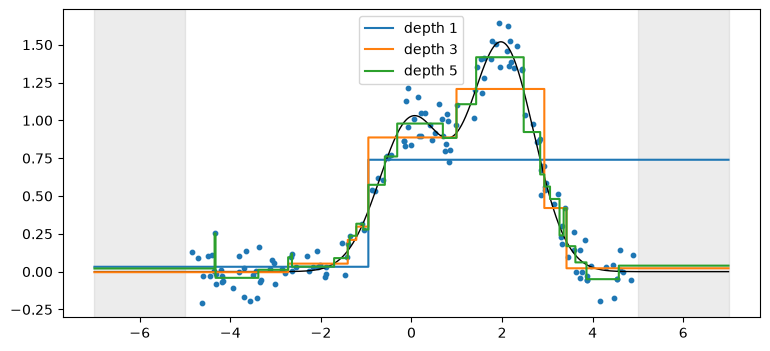

In [13]:
def step_predict(fit, xs):
    return np.asarray(fit["values"])[np.searchsorted(fit["thresholds"], xs, side="left")]


# The exported steps must reproduce sklearn's predictions exactly
xs = np.linspace(-7, 7, 2001)
for fit in fits[1:]:
    reg = DecisionTreeRegressor(max_depth=fit["max_depth"], random_state=SEED).fit(X_train, y_train)
    assert np.allclose(step_predict(fit, xs), reg.predict(xs.reshape(-1, 1)), atol=1e-6)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(X_train, y_train, s=10, c="tab:blue")
ax.plot(xs, f(xs), "k", lw=1)
for fit in fits[1::2]:
    ax.step(xs, step_predict(fit, xs), where="post", label=f"depth {fit['max_depth']}")
ax.axvspan(-7, -5, color="grey", alpha=0.15); ax.axvspan(5, 7, color="grey", alpha=0.15); ax.legend();

In [14]:
curve_x = np.linspace(-7, 7, 281)
dump("regression.json", {
    "seed": SEED, "n_train": n_train, "n_test": n_test, "noise": noise,
    "formula": "exp(-x^2) + 1.5*exp(-(x-2)^2)",
    "data_range": [-5, 5],
    "train": {"x": r(X_train.ravel(), 4), "y": r(y_train, 4)},
    "f_curve": {"x": r(curve_x, 4), "y": r(f(curve_x), 5)},   # covers [-7, 7] for the extrapolation beat
    "fits": fits,                          # max_depth 0 = single leaf (the mean)
})

wrote /Users/kashnitsky/Documents/learning_side_hassle/3b1b_mlcourse_claude/data/regression.json  (49.7 KB)


## 5. Twenty Questions

Scene 2 has no model in it, just counting. It still reads these numbers from here so every number on screen has a single source.

In [15]:
N_CANDIDATES = 64
halvings = [N_CANDIDATES]
while halvings[-1] > 1:
    halvings.append(halvings[-1] // 2)
assert 2 ** (len(halvings) - 1) == N_CANDIDATES

dump("twenty_questions.json", {
    "n_candidates": N_CANDIDATES,
    "jackpot_no_left": N_CANDIDATES - 1,           # "Is it Angelina Jolie?" -> No
    "halvings": halvings,                          # remaining after 0, 1, 2, ... balanced questions
    "questions_needed": len(halvings) - 1,         # log2(64) = 6
    "twenty": {
        "questions": 20,
        "candidates": 2 ** 20,
        "candidates_approx": round(2 ** 20, -6),  # "about a million"
    },
})

wrote /Users/kashnitsky/Documents/learning_side_hassle/3b1b_mlcourse_claude/data/twenty_questions.json  (0.4 KB)


## Scene 9 extras: extrapolation with the ball tree

Which leaf a ball past the data lands in (scene 9.10): ball 19 and a hypothetical ball at x = 25.

In [16]:
# Scene 9.10: balls past the data. Ball 19 and a ghost ball at 25 go through the same tree.
probes = [19, 25]
probe_leaves = ball_tree.apply(np.array(probes, dtype=float).reshape(-1, 1))
probe_preds = ball_tree.predict(np.array(probes, dtype=float).reshape(-1, 1))
extrap = [{"x": p, "leaf": int(l), "prediction": ["blue", "yellow"][int(c)]}
          for p, l, c in zip(probes, probe_leaves, probe_preds)]
leaf_id = extrap[0]["leaf"]
parent = next(n for n in ball_nodes if not n["leaf"] and leaf_id in (n["left"], n["right"]))
dump("regression_extra.json", {
    "ball_extrapolation": {
        "probes": extrap,
        "same_leaf": len({e["leaf"] for e in extrap}) == 1,
        "leaf_rule": f"x > {parent['t']}",     # the question that isolates this leaf
        "leaf_threshold": parent["t"],
    },
})
extrap


wrote /Users/kashnitsky/Documents/learning_side_hassle/3b1b_mlcourse_claude/data/regression_extra.json  (0.4 KB)


[{'x': 19, 'leaf': 10, 'prediction': 'blue'},
 {'x': 25, 'leaf': 10, 'prediction': 'blue'}]

## Scene 10: regrown loan tree and forest vote

Writes `loan_tree_v2.json` (scene 10). `loan_tree.json` (scene 1) is hand-written and not touched here.

In [17]:
# Scene 10 (wrap-up): the "regrown" loan tree, the applicant flips and the forest vote.
# Like loan_tree.json (scene 1), the loan trees are illustrative, not fitted: the article
# has no loan dataset. loan_tree.json is left untouched; everything for scene 10 goes to
# loan_tree_v2.json. Flag #6: v2 must ask a different root question yet still deny the
# same applicant, for a different reason. Both facts are asserted below.
loan_v1 = json.loads((DATA / "loan_tree.json").read_text())

APPLICANT = {"age": 23, "home": False, "income": 3800, "higher_edu": False}  # the scene-1 card
ASK = {  # question text -> how the applicant answers it
    "Owns a home?": APPLICANT["home"],
    "Income > 5,000?": APPLICANT["income"] > 5000,
    "Income > 2,000?": APPLICANT["income"] > 2000,
    "Age > 25?": APPLICANT["age"] > 25,
    "Higher education?": APPLICANT["higher_edu"],
}

loan_v2 = {
    "id": "v2_age25", "q": "Age > 25?",
    "no": {
        "id": "v2_edu", "q": "Higher education?",
        "no": {"id": "v2_deny_edu", "leaf": "Deny"},
        "yes": {
            "id": "v2_income2k", "q": "Income > 2,000?",
            "no": {"id": "v2_deny_income2k", "leaf": "Deny"},
            "yes": {"id": "v2_approve_income2k", "leaf": "Approve"},
        },
    },
    "yes": {
        "id": "v2_home", "q": "Owns a home?",
        "no": {
            "id": "v2_income5k", "q": "Income > 5,000?",
            "no": {"id": "v2_deny_income5k", "leaf": "Deny"},
            "yes": {"id": "v2_approve_income5k", "leaf": "Approve"},
        },
        "yes": {"id": "v2_approve_home", "leaf": "Approve"},
    },
}


def route(node):
    """Node ids the applicant visits, root to leaf."""
    path = [node["id"]]
    while "leaf" not in node:
        node = node["yes" if ASK[node["q"]] else "no"]
        path.append(node["id"])
    return path, node["leaf"]


def find(node, nid):
    if node["id"] == nid:
        return node
    for b in ("no", "yes"):
        if b in node and (hit := find(node[b], nid)):
            return hit


path_v1, out_v1 = route(loan_v1)
path_v2, out_v2 = route(loan_v2)
assert out_v1 == out_v2 == "Deny"
assert loan_v1["q"] != loan_v2["q"]  # a different root question
reasons_v1 = [find(loan_v1, i)["q"] for i in path_v1[:-1]]
reasons_v2 = [find(loan_v2, i)["q"] for i in path_v2[:-1]]
assert set(reasons_v1).isdisjoint(reasons_v2)  # a different reason for the same denial

# 10.4: six past applicants (0 = repaid, 1 = defaulted); three of them flip.
rng10 = np.random.default_rng(SEED)
past_before = [0, 1, 0, 0, 1, 0]
flipped = sorted(rng10.choice(len(past_before), size=3, replace=False).tolist())
past_after = [1 - c if i in flipped else c for i, c in enumerate(past_before)]

# 10.8: a forest of 120 trees. Each icon is a depth-2 tree with 4 leaves; the applicant
# lands in one of them and that leaf's class is the tree's vote.
N_TREES, N_DENY = 120, 87
votes = np.array(["Deny"] * N_DENY + ["Approve"] * (N_TREES - N_DENY))
rng10.shuffle(votes)
forest = []
for v in votes:
    leaves = rng10.choice(["Deny", "Approve"], size=4).tolist()
    landing = int(rng10.integers(4))
    leaves[landing] = str(v)
    forest.append({"leaves": leaves, "landing": landing, "vote": str(v)})
REPS = 30  # vote dots that actually fly: every 4th tree
rep_idx = list(range(0, N_TREES, N_TREES // REPS))[:REPS]

dump("loan_tree_v2.json", {
    "_note": "Scene 10. Illustrative (not fitted), like loan_tree.json. v2 = the tree 'regrown' after a few past applicants change.",
    "applicant": APPLICANT,
    "v1_path": path_v1, "v1_reasons": reasons_v1,
    "v2": loan_v2,
    "v2_path": path_v2, "v2_reasons": reasons_v2,
    "past_applicants": {"before": past_before, "after": past_after, "flipped": flipped},
    "forest": {
        "n_trees": N_TREES,
        "tally": {"Deny": int((votes == "Deny").sum()), "Approve": int((votes == "Approve").sum())},
        "majority": "Deny" if (votes == "Deny").sum() > N_TREES / 2 else "Approve",
        "trees": forest,
        "representatives": rep_idx,
        "rep_tally": {"Deny": sum(forest[i]["vote"] == "Deny" for i in rep_idx),
                      "Approve": sum(forest[i]["vote"] == "Approve" for i in rep_idx)},
    },
})


wrote /Users/kashnitsky/Documents/learning_side_hassle/3b1b_mlcourse_claude/data/loan_tree_v2.json  (16.9 KB)


## 6. The bank clients: age (and salary)

Scene 6. The 11 clients from the article's numeric-feature example (`data` / `data2`):
age, salary in $k/year, and loan default (1 = defaulted). Candidate cuts are midpoints between
neighboring distinct values. A *switch point* is a midpoint where the class changes between
neighbors. The article's age-only tree uses sklearn's default `criterion="gini"`.

In [18]:
AGE = [17, 64, 18, 20, 38, 49, 55, 25, 29, 31, 33]
SALARY = [25, 80, 22, 36, 37, 59, 74, 70, 33, 102, 88]
DEFAULT = [1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1]
age_y = np.array(DEFAULT)


def gini(counts):
    counts = np.asarray(counts, dtype=float)
    p = counts / counts.sum()
    return float(1 - (p**2).sum())


def cut_table(values):
    """Every midpoint between neighboring distinct values, with entropy IG and Gini gain."""
    v = np.asarray(values)
    cnt = lambda m: [int((age_y[m] == 0).sum()), int((age_y[m] == 1).sum())]
    parent = cnt(np.ones(len(v), bool))
    s = np.unique(v)
    out = []
    for a, b in zip(s[:-1], s[1:]):
        t = (a + b) / 2
        L, R = cnt(v <= t), cnt(v > t)
        classes = set(age_y[v == a]) | set(age_y[v == b])
        n = len(v)
        out.append({"t": r(t), "left": L, "right": R,
                    "switch": len(classes) > 1,
                    "ig": r(info_gain(parent, [L, R])),
                    "gini_gain": r(gini(parent) - sum(L) / n * gini(L) - sum(R) / n * gini(R))})
    return parent, out


age_parent, age_cuts = cut_table(AGE)
salary_parent, salary_cuts = cut_table(SALARY)
age_switch = [c["t"] for c in age_cuts if c["switch"]]
salary_switch = [c["t"] for c in salary_cuts if c["switch"]]
best_age = max(age_cuts, key=lambda c: c["ig"])
ig_at = {c["t"]: c["ig"] for c in age_cuts}

# The article's trees (default criterion = gini)
age_tree = DecisionTreeClassifier(random_state=SEED).fit(np.array(AGE).reshape(-1, 1), age_y)
age_tree_thresholds = sorted({n["threshold"] for n in tree_nodes(age_tree, ["repaid", "defaulted"]) if not n["leaf"]})
age_root = tree_nodes(age_tree, ["repaid", "defaulted"])[0]["threshold"]

assert age_switch == [19.0, 22.5, 30.0, 32.0, 43.5], age_switch
assert age_tree_thresholds == age_switch and age_root == 43.5
assert best_age["t"] == 43.5 and max(age_cuts, key=lambda c: c["gini_gain"])["t"] == 43.5
print("age switch points", age_switch, " best", best_age["t"], best_age["ig"])
print("17.5 -> 19:", ig_at[17.5], "->", ig_at[19.0])
print("salary switch points", salary_switch)
print("parent entropy", r(entropy(age_parent)))

age switch points [19.0, 22.5, 30.0, 32.0, 43.5]  best 43.5 0.40401
17.5 -> 19: 0.084939 -> 0.18315
salary switch points [34.5, 36.5, 48.0, 64.5, 72.0, 84.0, 95.0]
parent entropy 0.99403


In [19]:
p_grid = np.linspace(0, 1, 101)
dump("age.json", {
    "clients": [{"age": a, "salary": s, "defaulted": d} for a, s, d in zip(AGE, SALARY, DEFAULT)],  # article order
    "parent_counts": age_parent,                 # [repaid, defaulted]
    "parent_entropy": r(entropy(age_parent)),
    "age_cuts": age_cuts,                        # every midpoint; "switch" marks a class change
    "age_switch_points": age_switch,
    "age_best": best_age,
    "age_tree_thresholds": age_tree_thresholds,  # sklearn, criterion="gini" (the article's tree)
    "age_tree_root": age_root,
    "bad_cut": {"t": 17.5, "ig": ig_at[17.5], "slide_to": 19.0, "ig_after": ig_at[19.0]},
    "salary_cuts": salary_cuts,
    "salary_switch_points": salary_switch,
    "impurity_curves": {                         # for the Gini aside (two classes, p = share of class 1)
        "p": r(p_grid, 3),
        "entropy": r([entropy([p, 1 - p]) for p in p_grid], 4),
        "gini": r([gini([p, 1 - p]) for p in p_grid], 4),
        "misclassification": r([min(p, 1 - p) for p in p_grid], 4),
    },
})

wrote /Users/kashnitsky/Documents/learning_side_hassle/3b1b_mlcourse_claude/data/age.json  (8.3 KB)


In [20]:
# Scene 4: the rejected "plain average" score, (S_left + S_right) / 2, for every threshold
balls = json.loads((DATA / "balls.json").read_text())
for d in balls["thresholds"]:
    d["plain_avg"] = r((entropy(d["left"]) + entropy(d["right"])) / 2)
(DATA / "balls.json").write_text(json.dumps(balls, indent=1) + "\n")
print("plain average at x <= 0:", balls["thresholds"][0]["plain_avg"], " at x <= 12:", balls["thresholds"][12]["plain_avg"])

plain average at x <= 0: 0.499  at x <= 12: 0.776455


## Scene 7 extras: root-cut sweep, node boxes, staircase, test point

Writes `tree2d_extra.json` (scene 7), from the 2D toy data in section 2.

In [21]:
# Scene 7 extras -> tree2d_extra.json. Uses train_data / train_labels / bounds / trees2d from section 2.
# root_sweep: IG of every candidate root cut on each axis (midpoints between sorted values, as sklearn does).
# node_boxes: the region of every node of the depth-3 tree, so the scene never computes geometry.
# boundary: the class boundary ("staircase") of a tree = the shared edges between leaves predicting different classes.
# test_point: the scene-7.13 probe and its path through the depth-3 tree.
def node_boxes(nodes, bounds):
    boxes = {}

    def walk(i, box):
        boxes[i] = r(box)
        n = nodes[i]
        if n["leaf"]:
            return
        f, thr = n["feature"], n["threshold"]
        lo, hi = [list(x) for x in box], [list(x) for x in box]
        lo[f][1] = thr
        hi[f][0] = thr
        walk(n["left"], lo)
        walk(n["right"], hi)

    walk(0, [list(b) for b in bounds])
    return [{"node": i, "box": boxes[i]} for i in sorted(boxes)]


def class_boundary(leaves, eps=1e-9):
    segs = []
    for i, a in enumerate(leaves):
        for b in leaves[i + 1:]:
            if a["prediction"] == b["prediction"]:
                continue
            for f in (0, 1):  # f = axis the shared edge is perpendicular to
                o = 1 - f
                for s, t in ((a, b), (b, a)):
                    if abs(s["box"][f][1] - t["box"][f][0]) < eps:
                        lo = max(s["box"][o][0], t["box"][o][0])
                        hi = min(s["box"][o][1], t["box"][o][1])
                        if hi - lo > eps:
                            p, q = [0.0, 0.0], [0.0, 0.0]
                            p[f] = q[f] = s["box"][f][1]
                            p[o], q[o] = lo, hi
                            segs.append({"start": r(p), "end": r(q)})
    return segs


root_counts = [int((train_labels == 0).sum()), int((train_labels == 1).sum())]
root_sweep = []
for f in (0, 1):
    v = np.unique(train_data[:, f])
    cand = (v[:-1] + v[1:]) / 2
    igs = []
    for t in cand:
        m = train_data[:, f] <= t
        L = [int((train_labels[m] == 0).sum()), int((train_labels[m] == 1).sum())]
        R = [root_counts[0] - L[0], root_counts[1] - L[1]]
        igs.append(info_gain(root_counts, [L, R]))
    k = int(np.argmax(igs))
    root_sweep.append({"feature": f, "thresholds": r(cand, 4), "ig": r(igs, 4),
                       "best_threshold": r(cand[k]), "best_ig": r(igs[k])})

d3 = next(t for t in trees2d if t["max_depth"] == 3)
d5 = next(t for t in trees2d if t["max_depth"] == 5)
best = max(root_sweep, key=lambda s: s["best_ig"])
assert best["feature"] == d3["nodes"][0]["feature"]
assert abs(best["best_threshold"] - d3["nodes"][0]["threshold"]) < 1e-4
assert abs(best["best_ig"] - d3["nodes"][0]["gain"]) < 1e-4

TEST_POINT = [3.0, 0.3]  # chosen to take a yes/no/no path through three different questions
clf3 = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED).fit(train_data, train_labels)
tp_path = clf3.decision_path(np.array([TEST_POINT])).indices.tolist()
tp_leaf = int(clf3.apply(np.array([TEST_POINT]))[0])

CLOUD_MEANS = np.array([[0.0, 0.0], [2.0, 2.0]])  # the generator's locs (section 2)
overlap = {"center": r(CLOUD_MEANS.mean(axis=0)), "radius": 1.2}  # the 7.3 highlight, in data units

dump("tree2d_extra.json", {
    "overlap": overlap,
    "root_sweep": root_sweep,
    "depth3_node_boxes": node_boxes(d3["nodes"], bounds),
    "boundary": {"depth3": class_boundary(d3["leaves"]), "depth5": class_boundary(d5["leaves"])},
    "test_point": {"x": TEST_POINT, "path": tp_path, "leaf": tp_leaf,
                   "prediction": int(clf3.predict(np.array([TEST_POINT]))[0])},
})
print({s["feature"]: (s["best_threshold"], s["best_ig"]) for s in root_sweep}, tp_path)

wrote /Users/kashnitsky/Documents/learning_side_hassle/3b1b_mlcourse_claude/data/tree2d_extra.json  (14.7 KB)
{0: (1.348741, 0.3879), 1: (1.210845, 0.412055)} [0, 1, 5, 7]


## Scene 8 extras: overfitting

Slider partitions (depth and `min_samples_leaf`), stray-point slivers, a cost-complexity-pruned 2D tree, the 21st ball and a pruned ball tree -> `overfitting.json`.

In [22]:
# Scene 8: overfitting. Slider partitions, stray-point slivers, the 21st ball, the pruned ball tree,
# and a cost-complexity-pruned 2D tree for the "prune back" icon.
from sklearn.model_selection import cross_val_score

full2d = DecisionTreeClassifier(criterion="entropy", random_state=SEED).fit(train_data, train_labels)
full_nodes = tree_nodes(full2d, class_names=[0, 1])
_, full_leaves = regions(full_nodes, bounds)

# 8.2 depth slider stops (indices into toy2d.json "trees"; None = unlimited)
DEPTH_STOPS = [3, 6, 10, None]

# 8.3 slivers: tiny leaves of the unlimited tree that predict the opposite of the depth-3 tree there,
# smallest area first. "points" are indices into toy2d.json "points".
d3 = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED).fit(train_data, train_labels)
leaf_of = full2d.apply(train_data)
slivers = []
for lf in full_leaves:
    (x0, x1), (y0, y1) = lf["box"]
    inside = np.where(leaf_of == lf["node"])[0]
    if len(inside) > 2 or d3.predict(train_data[inside]).mean() == lf["prediction"]:
        continue
    slivers.append({"node": lf["node"], "box": lf["box"], "prediction": lf["prediction"],
                    "points": inside.tolist(), "area": r((x1 - x0) * (y1 - y0), 4)})
slivers.sort(key=lambda s: s["area"])
print("slivers:", [(s["node"], s["points"], s["area"]) for s in slivers])

# 8.13 min_samples_leaf slider stops (no depth cap)
MIN_LEAF_STOPS = [1, 5, 10, 20]
min_leaf = []
for k in MIN_LEAF_STOPS:
    clf = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=k, random_state=SEED).fit(train_data, train_labels)
    nodes = tree_nodes(clf, class_names=[0, 1])
    segments, leaves = regions(nodes, bounds)
    min_leaf.append({"min_samples_leaf": k, "actual_depth": int(clf.get_depth()), "n_leaves": int(clf.get_n_leaves()),
                     "train_accuracy": r(clf.score(train_data, train_labels)), "segments": segments, "leaves": leaves})
    print(f"min_samples_leaf={k:2d}  leaves={clf.get_n_leaves():2d}  train acc={clf.score(train_data, train_labels):.3f}")

# 8.14 cost-complexity pruning of the unlimited 2D tree, alpha picked by the same repeated CV as depth_cv.json.
# "removed" = roots of the subtrees that get cut, as node ids of the unlimited tree.
cv8 = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
alphas = full2d.cost_complexity_pruning_path(train_data, train_labels).ccp_alphas[:-1]
ccp_scores = [cross_val_score(DecisionTreeClassifier(criterion="entropy", ccp_alpha=a, random_state=SEED),
                              train_data, train_labels, cv=cv8).mean() for a in alphas]
best_alpha = float(alphas[int(np.argmax(ccp_scores))])
pruned2d = DecisionTreeClassifier(criterion="entropy", ccp_alpha=best_alpha, random_state=SEED).fit(train_data, train_labels)


def kept_ids(full, pruned):
    """Node ids of `full` that survive in `pruned` (matched by walking both trees in step)."""
    keep, removed = [], []

    def walk(i, j):
        keep.append(i)
        fl, pl = full.tree_.children_left, pruned.tree_.children_left
        if fl[i] == -1:
            return
        if pl[j] == -1:
            removed.append(i)
            return
        assert full.tree_.feature[i] == pruned.tree_.feature[j]
        assert np.isclose(full.tree_.threshold[i], pruned.tree_.threshold[j])
        walk(int(fl[i]), int(pl[j]))
        walk(int(full.tree_.children_right[i]), int(pruned.tree_.children_right[j]))

    walk(0, 0)
    return keep, removed


ccp_keep, ccp_removed = kept_ids(full2d, pruned2d)
print(f"ccp alpha={best_alpha:.4f}  leaves {full2d.get_n_leaves()} -> {pruned2d.get_n_leaves()}  "
      f"CV acc={max(ccp_scores):.3f}  subtrees cut at {ccp_removed}")

# 8.5-8.8 the 21st ball and a pruned ball tree.
# Pruned tree: scene 5's tree with every split that isolates a single ball collapsed back into one leaf
# (that leaf predicts its majority color). sklearn's cost-complexity path skips this tree (it jumps
# straight to the root), so the rule is applied by hand to the exported nodes.
by_id = {n["id"]: n for n in ball_nodes}
pruned_ball_nodes = []
collapsed = {n["id"] for n in ball_nodes if not n["leaf"]
             and min(by_id[n["left"]]["samples"], by_id[n["right"]]["samples"]) == 1
             and by_id[n["left"]]["leaf"] and by_id[n["right"]]["leaf"]}
dropped = {c for i in collapsed for c in (by_id[i]["left"], by_id[i]["right"])}
for n in ball_nodes:
    if n["id"] in dropped:
        continue
    n = dict(n)
    if n["id"] in collapsed:
        for k in ("feature", "threshold", "left", "right", "gain", "question", "t"):
            n.pop(k)
        n["leaf"] = True
        n["collapsed"] = True
    pruned_ball_nodes.append(n)
pruned_by_id = {n["id"]: n for n in pruned_ball_nodes}


def pruned_predict(v):
    n = pruned_by_id[0]
    while not n["leaf"]:
        n = pruned_by_id[n["left"] if v <= n["threshold"] else n["right"]]
    return n["id"], n["prediction"]


wrong = [int(i) for i in x if pruned_predict(i)[1] != colors[i]]

# The new ball sits inside the one-ball leaf "x > 18". Its true color follows the neighbourhood:
# the majority of the 5 nearest training balls.
NEW_X = 18.7
nearest = np.argsort(np.abs(x - NEW_X))[:5]
new_true = ["blue", "yellow"][int(round(y[nearest].mean()))]
new_ball = {
    "x": NEW_X, "true_color": new_true, "nearest": sorted(int(i) for i in nearest),
    "full_leaf": int(ball_tree.apply([[NEW_X]])[0]),
    "full_prediction": ["blue", "yellow"][int(ball_tree.predict([[NEW_X]])[0])],
    "pruned_leaf": pruned_predict(NEW_X)[0],
    "pruned_prediction": pruned_predict(NEW_X)[1],
}
assert new_ball["full_prediction"] != new_true and new_ball["pruned_prediction"] == new_true
print("new ball:", new_ball, " pruned tree wrong on balls", wrong)
for n in pruned_ball_nodes:
    print("  " * n["depth"] + (n.get("question") or f"leaf {n['prediction']}"), n["counts"], n["balls"])

dump("overfitting.json", {
    "depth_stops": DEPTH_STOPS,
    "slivers": slivers,
    "min_leaf": min_leaf,
    "ccp": {"alpha": r(best_alpha), "cv_accuracy": r(max(ccp_scores)), "n_leaves_full": int(full2d.get_n_leaves()),
            "n_leaves_pruned": int(pruned2d.get_n_leaves()), "kept": ccp_keep, "removed": ccp_removed,
            "full_nodes": full_nodes},
    "new_ball": new_ball,
    "pruned_ball_tree": {"n_questions": sum(not n["leaf"] for n in pruned_ball_nodes),
                         "nodes": pruned_ball_nodes, "wrong": wrong},
})


slivers: [(20, [127], 0.0062), (33, [34], 0.0331), (47, [52], 0.0367), (7, [176], 0.0373), (22, [101], 0.0412), (11, [140, 144], 0.0418), (16, [124], 0.0647), (49, [2], 0.1738), (35, [5], 0.2766), (30, [63], 0.3113)]
min_samples_leaf= 1  leaves=26  train acc=1.000
min_samples_leaf= 5  leaves=12  train acc=0.930
min_samples_leaf=10  leaves= 9  train acc=0.915
min_samples_leaf=20  leaves= 6  train acc=0.895


ccp alpha=0.0310  leaves 26 -> 5  CV acc=0.883  subtrees cut at [4, 23, 37, 42]
new ball: {'x': 18.7, 'true_color': 'yellow', 'nearest': [15, 16, 17, 18, 19], 'full_leaf': 10, 'full_prediction': 'blue', 'pruned_leaf': 8, 'pruned_prediction': 'yellow'}  pruned tree wrong on balls [0, 19]
x <= 12 [9, 11] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  x <= 8 [8, 5] [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    x <= 4 [4, 5] [0, 1, 2, 3, 4, 5, 6, 7, 8]
      leaf blue [4, 1] [0, 1, 2, 3, 4]
      leaf yellow [0, 4] [5, 6, 7, 8]
    leaf blue [4, 0] [9, 10, 11, 12]
  leaf yellow [1, 6] [13, 14, 15, 16, 17, 18, 19]
wrote /Users/kashnitsky/Documents/learning_side_hassle/3b1b_mlcourse_claude/data/overfitting.json  (36.5 KB)
